**Q1. Design and implement an image classification CNN model to classify a daatset of images using deep feed forward neural network.Record accuracy as per number of epochs and subparts (a-d). Use MNIST data and CIFAR-10 dataset. Record the time required to run the program using CPU and GPU**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Load MNIST dataset
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

# Load CIFAR-10 dataset
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

In [ ]:
print(f"...MNIST TRAINING SET DETAILS...")
print(f"Shape of x_train_mnist: {x_train_mnist.shape}")
print(f"Shape of y_train_mnist: {y_train_mnist.shape}")
print(f"...CIFAR-10 TRAINING SET DETAILS...")
print(f"Shape of x_train_cifar: {x_train_cifar.shape}")
print(f"Shape of y_train_cifar: {y_train_cifar.shape}")

Shape of x_train_mnist: (60000, 28, 28)
Shape of y_train_mnist: (60000,)
Shape of x_train_cifar: (50000, 32, 32, 3)
Shape of y_train_cifar: (50000, 1)


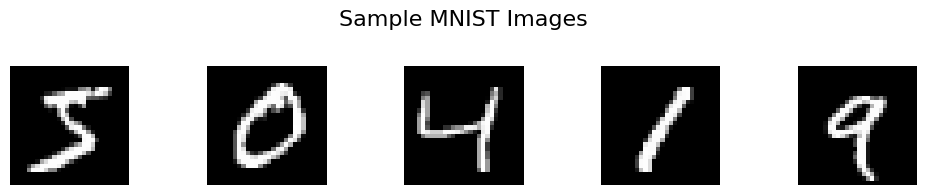

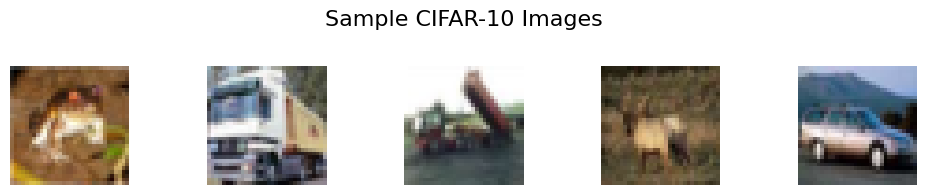

In [ ]:
import matplotlib.pyplot as plt

# Visualize sample MNIST images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train_mnist[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Visualize sample CIFAR-10 images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train_cifar[i])
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import numpy as np

# 1. Convert to float32 data type
x_train_mnist = x_train_mnist.astype('float32')
x_test_mnist = x_test_mnist.astype('float32')

# 2. Normalize pixel values
x_train_mnist /= 255.0
x_test_mnist /= 255.0

# 3. Reshape to include channel dimension (28, 28, 1)
x_train_mnist = x_train_mnist.reshape(x_train_mnist.shape[0], 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(x_test_mnist.shape[0], 28, 28, 1)

# 4. One-hot encode labels
num_classes_mnist = 10
y_train_mnist = tf.keras.utils.to_categorical(y_train_mnist, num_classes_mnist)
y_test_mnist = tf.keras.utils.to_categorical(y_test_mnist, num_classes_mnist)

print("MNIST data preprocessing complete.")
print(f"New shape of x_train_mnist: {x_train_mnist.shape}")
print(f"New shape of y_train_mnist: {y_train_mnist.shape}")
print(f"New shape of x_test_mnist: {x_test_mnist.shape}")
print(f"New shape of y_test_mnist: {y_test_mnist.shape}")

MNIST data preprocessing complete.
New shape of x_train_mnist: (60000, 28, 28, 1)
New shape of y_train_mnist: (60000, 10, 10)
New shape of x_test_mnist: (10000, 28, 28, 1)
New shape of y_test_mnist: (10000, 10, 10)


In [ ]:
mnist_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

print("MNIST CNN model created successfully.")

MNIST CNN model created successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
mnist_model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28, 28, 1)), # Specify input shape using Input layer
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

print("MNIST CNN model created successfully without input_shape warning.")

MNIST CNN model created successfully without input_shape warning.


In [ ]:
mnist_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("MNIST CNN model compiled successfully.")

MNIST CNN model compiled successfully.


In [ ]:
history_mnist = mnist_model.fit(x_train_mnist, y_train_mnist, epochs=10, batch_size=32, validation_data=(x_test_mnist, y_test_mnist))

print("MNIST CNN model trained successfully.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.4610 - loss: 1.4860 - val_accuracy: 0.9245 - val_loss: 0.2591
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9247 - loss: 0.2506 - val_accuracy: 0.9447 - val_loss: 0.1736
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9464 - loss: 0.1775 - val_accuracy: 0.9619 - val_loss: 0.1217
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9588 - loss: 0.1333 - val_accuracy: 0.9643 - val_loss: 0.1119
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9650 - loss: 0.1140 - val_accuracy: 0.9670 - val_loss: 0.0996
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9705 - loss: 0.0956 - val_accuracy: 0.9741 - val_loss: 0.0804
Epoch 7/10
 787/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.9735 - loss: 0.0855

KeyboardInterrupt: 